## Preprocess Data (CME)
- Input: `data/experimental/vol/raw/***/***.tif` (Original sub-volume data)
- Intermediate: `data/experimental/vol/formatted/***/***.tif` (Reformatted sub-volume data)
- Output: `data/experimental/pts` (Point signals)

In [1]:
import sys
from pathlib import Path
import os
import tifffile as tiff
import numpy as np
import json

project_root = Path().resolve().parent
sys.path.append(str(project_root / "src"))

In [68]:
## To reload

import importlib
import data_generation.preprocess as preprocess
importlib.reload(preprocess)

<module 'data_generation.preprocess' from '/mmfs1/gscratch/matsulab/sim/pinn-exploration-model/src/data_generation/preprocess.py'>

### 1. Preprocessing
Load the subvolume data and resize it to ensure consistent dimensions across all shapes. Then apply a CLAHE filter to enhance contrast and save the result.
- Input: `data/experimental/vol/raw/***/***.tif` (Original sub-volume data)
- Output: `data/experimental/vol/formatted/***/***.tif` (Reformatted sub-volume data)

In [2]:
from data_generation.preprocess import resize_cryoet_to_cube, clahe_volume_slicewise_fast

#### Data ID ####
data_id = "jrc_cos7-1b"
shape = "bud-11"

#### Global Parameters (do not change) ####
N_voxel = 176 
I_max   = 255

#### Import Raw TIFF File ####
raw_data_path = f"../data/experimental/vol/raw/{data_id}/{shape}.tif"
cryoet = tiff.imread(raw_data_path)
cryoet = np.clip(cryoet/I_max, 0, 1)
cryoet = 1 - cryoet

#### Resize ####
cryoet_resized, transforms = resize_cryoet_to_cube(cryoet, N_voxel)

#### Enhance Contrast ####
clahe_vol = clahe_volume_slicewise_fast(cryoet_resized, clipLimit=4.0, tileGridSize=(2, 2))

#### Metrics ####
print("--------- Data shape ---------")
print("Raw    :", cryoet.shape)
print("Resized:", cryoet_resized.shape)
print("CLAHE  :", clahe_vol.shape, "\n")
print("--------- Intensity (min, max) ---------")
print("Raw    :", cryoet.min(), cryoet.max())
print("Resized:", cryoet_resized.min(), cryoet_resized.max())
print("CLAHE  :", clahe_vol.min(), clahe_vol.max())

--------- Data shape ---------
Raw    : (84, 148, 148)
Resized: (176, 176, 176)
CLAHE  : (176, 176, 176) 

--------- Intensity (min, max) ---------
Raw    : 0.02352941176470591 0.7529411764705882
Resized: 0.0 0.7529411764705882
CLAHE  : 0.015686275 0.93333334


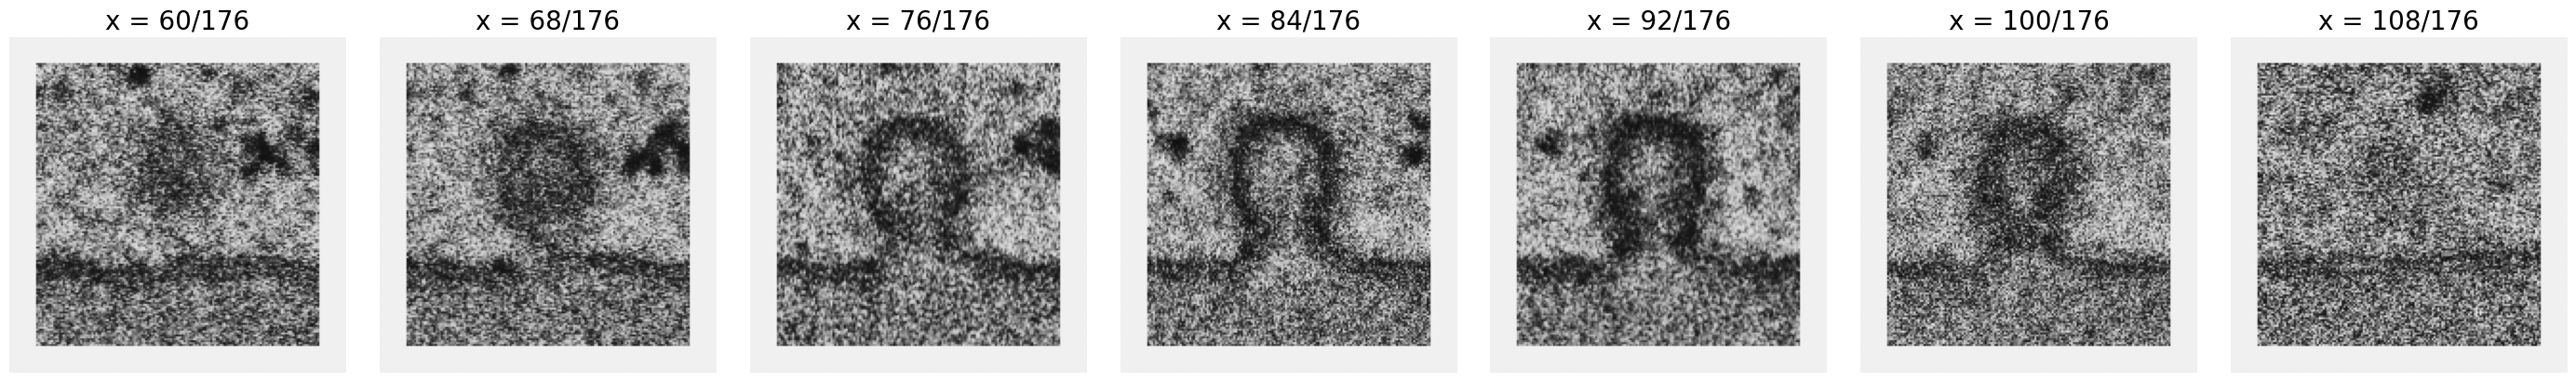

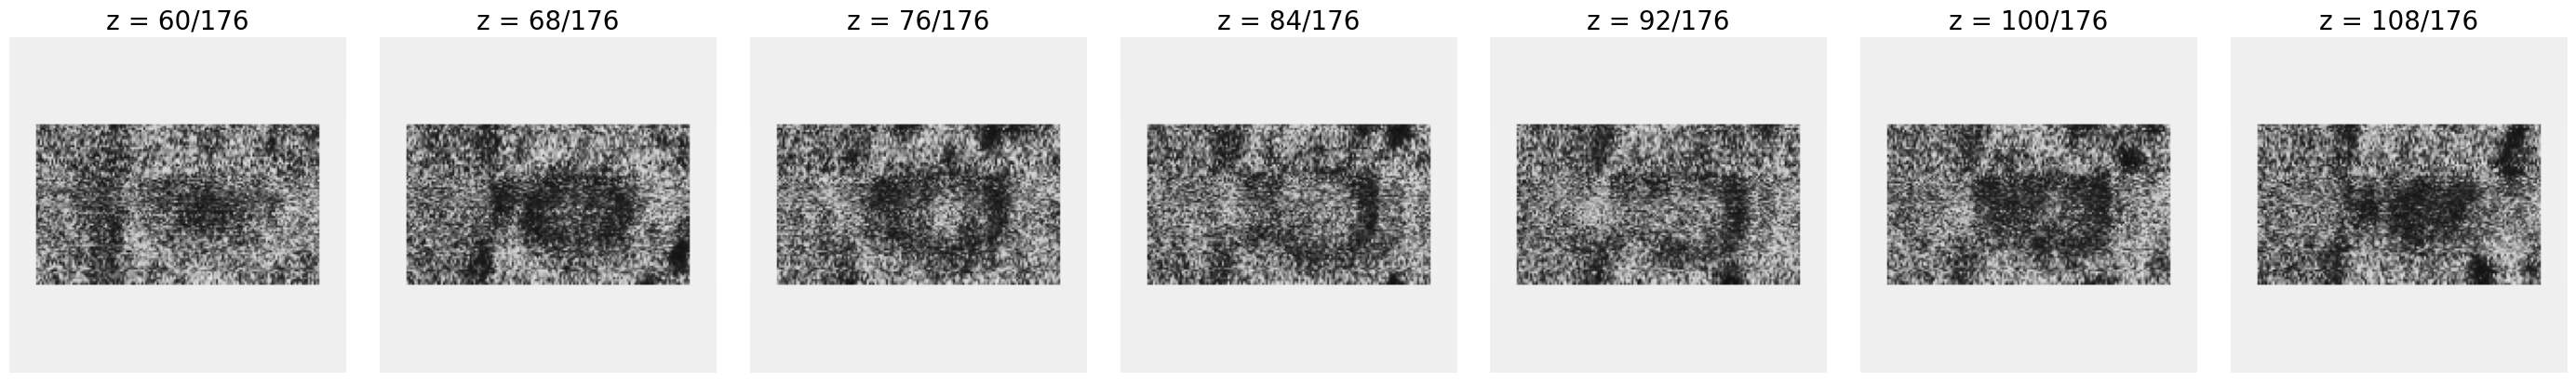

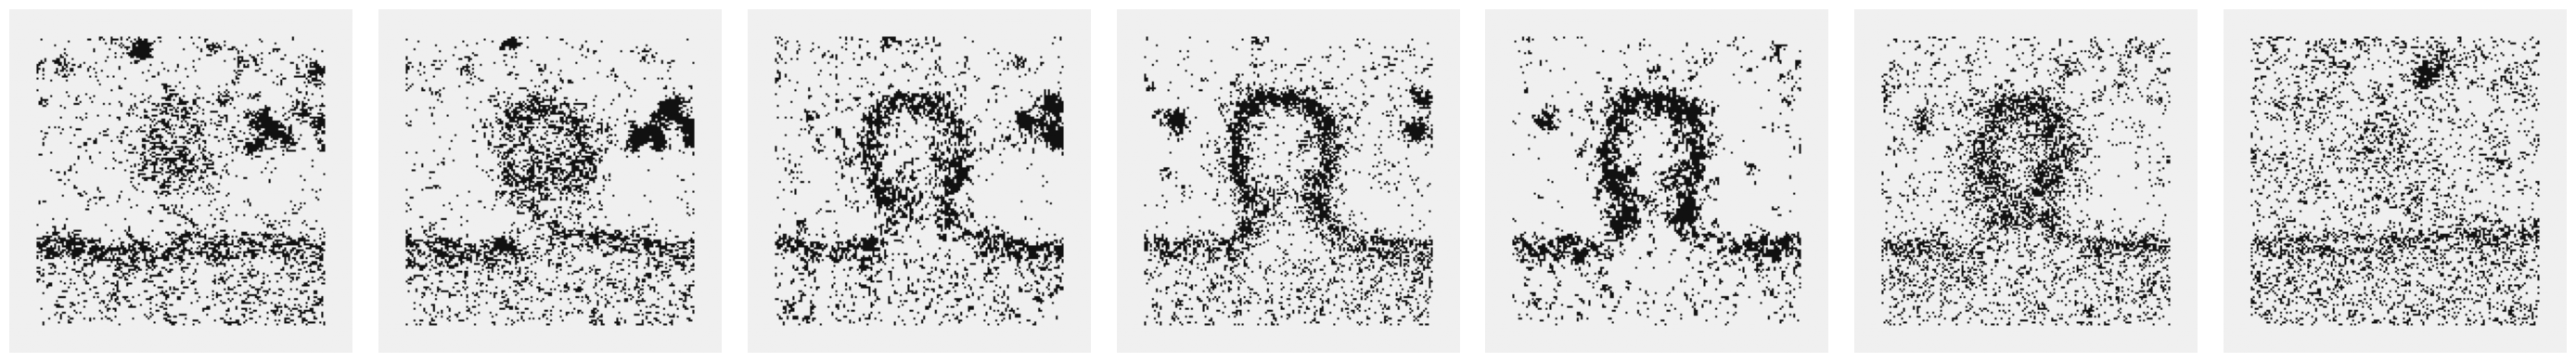

In [4]:
from data_generation.preprocess import overlay_points_on_cryoet

#### Parameters ####
threshold = 0.75 # 0.8
slices = list(range(60, 110, 8))
# slices = list(range(64, 111, 7))
# slices = list(range(103, 111, 1))

# visualize = cryoet
# visualize = cryoet_resized
visualize = clahe_vol

#### Visualize Data ####
overlay_points_on_cryoet(cryoet=visualize, axis='x', slice_index=slices, show_title=True)
overlay_points_on_cryoet(cryoet=visualize, axis='z', slice_index=slices, show_title=True)
overlay_points_on_cryoet(cryoet=visualize, axis='x', slice_index=slices, threshold=threshold)

#### Save Reformatted Data ####
save_path = f"../data/experimental/vol/formatted/{data_id}/{shape}.tif"
# tiff.imwrite(save_path, 1-clahe_vol)

### 2. Points Extraction
- Input: `data/experimental/vol/formatted/***/***.tif` (Reformatted sub-volume data)
- Output: `data/experimental/pts/edge/***/pt_e_***.npz`
- Output: `data/experimental/pts/sign/***/pt_s_***.npz`
- Output: `data/experimental/pts/phys/pt_p_general.npz`

#### Edge/bulk signal
Extract edge/bulk signal based on simple thresholding method

edge size:  54518.0
bulk size:  109036.0


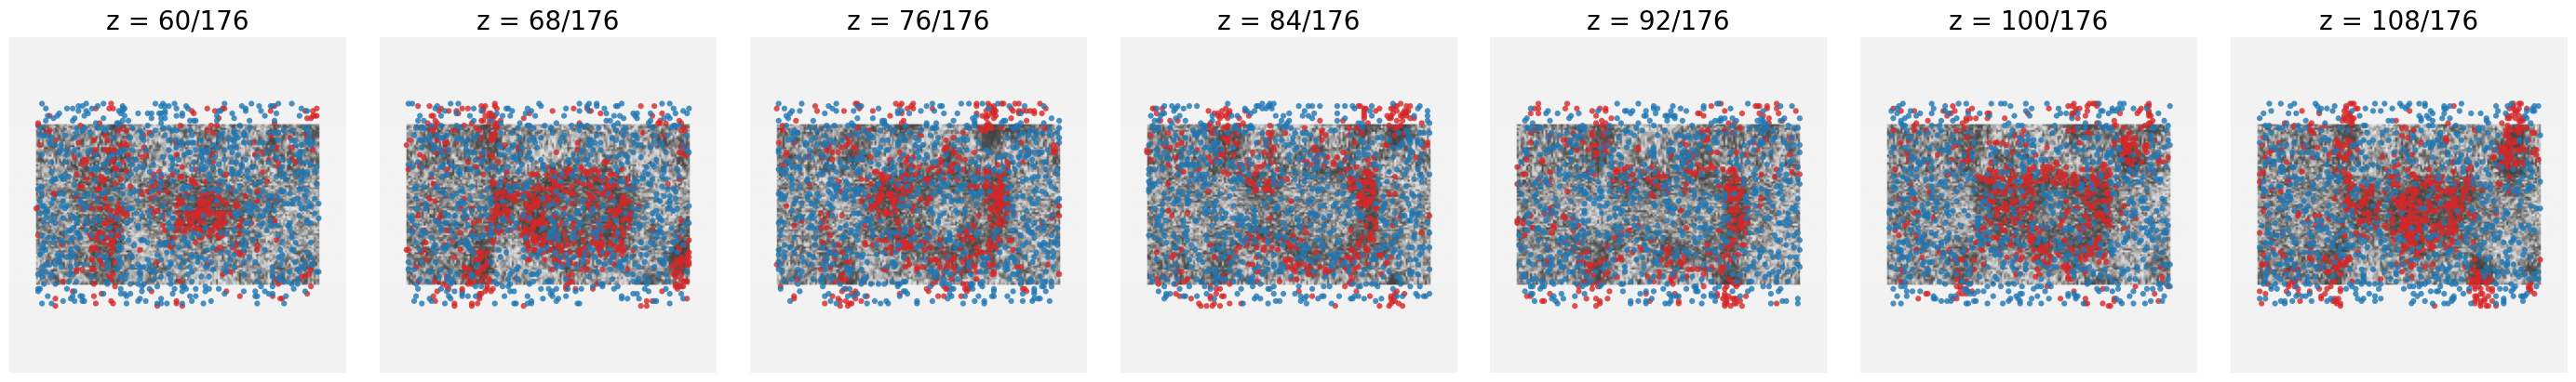

In [9]:
from data_generation.preprocess import downsample_binary_mask_to_fraction, overlay_points_on_cryoet, build_data_edge_from_masks
from pinn.utils import save_pts_data, load_pts_data

#### Parameters ####
# threshold = 0.8
target_edge = 0.01
target_bulk = 0.02
# slices = list(range(60, 110, 8))
# shape = "bud-11"

#### Import TIFF (if starting from here) ####
# data_path = f"../data/experimental/vol/formatted/{data_id}/{shape}.tif"
# cryoet = tiff.imread(data_path)
# cryoet = 1 - cryoet

#### Obtain mask for the original volume ####
xmin = transforms[2]["start_dst"] 
xmax = transforms[2]["end_dst"]
ymin = transforms[1]["start_dst"] 
ymax = transforms[1]["end_dst"]
zmin = transforms[0]["start_dst"] 
zmax = transforms[0]["end_dst"]
z, y, x = np.indices(clahe_vol.shape)
mask = (
    (x >= xmin) & (x < xmax) &
    (y >= ymin) & (y < ymax) &
    (z >= zmin) & (z < zmax)
)

#### Sample edge/bulk signals ####
edge = (clahe_vol > threshold)
bulk = (~edge) & mask
edge = downsample_binary_mask_to_fraction(edge, target_frac=target_edge, seed=0)
bulk = downsample_binary_mask_to_fraction(bulk, target_frac=target_bulk, seed=0)
edge = edge.astype(np.float32)
bulk = bulk.astype(np.float32)
print("edge size: ", edge.sum())
print("bulk size: ", bulk.sum())

#### Save point data ####
data_edge = build_data_edge_from_masks(edge=edge, bulk=bulk, volume_shape=clahe_vol.shape)
meta_data ={
    "type": "edge",
    "label_meaning": {1: "edge", 0: "bulk"},
    "GRID_SIZE": clahe_vol.shape[0],
    "edge_min": threshold,
    "target_edge": target_edge,
    "target_bulk": target_bulk,
    "shape": shape,
}
save_path = f"../data/experimental/pts/edge/{data_id}/pt_e_{shape}.npz"
os.makedirs(os.path.dirname(save_path), exist_ok=True)
# save_pts_data(data_edge, save_path, meta_data)

#### Visualize data ####
# data = load_pts_data(f"../data/experimental/pts/edge/{data_id}/pt_e_{shape}.npz", perm=(2,1,0))
data = load_pts_data(f"../data/experimental/pts/edge/{data_id}/pt_e_{shape}.npz", perm=(2,1,0), scale=(1.27, 1, 1))
edge = data["points"][data["label"] == 1]
bulk = data["points"][data["label"] == 0]
overlays = [
    {"data": edge, "label": "Edge", "color": "tab:red"},
    {"data": bulk, "label": "Bulk", "color": "tab:blue"},
]
overlay_points_on_cryoet(cryoet=clahe_vol, overlays=overlays, axis='z', slice_index=slices, cryo_alpha=0.8, show_title=True)

#### Inside/outside signal
Manually extract inside/outside signal using napari expansion.

In [28]:
# from data_generation.preprocess import napari_sign_labeler

#### Manually sample points and save data ####
## It should be done at local machine since it uses graphic user interface 
# %gui qt
# save_path = f"../dat/pt_s_{shape}.npz"
# viewer, pts_plus, pts_minus = napari_sign_labeler(normalized, save_path=save_path, size=5)

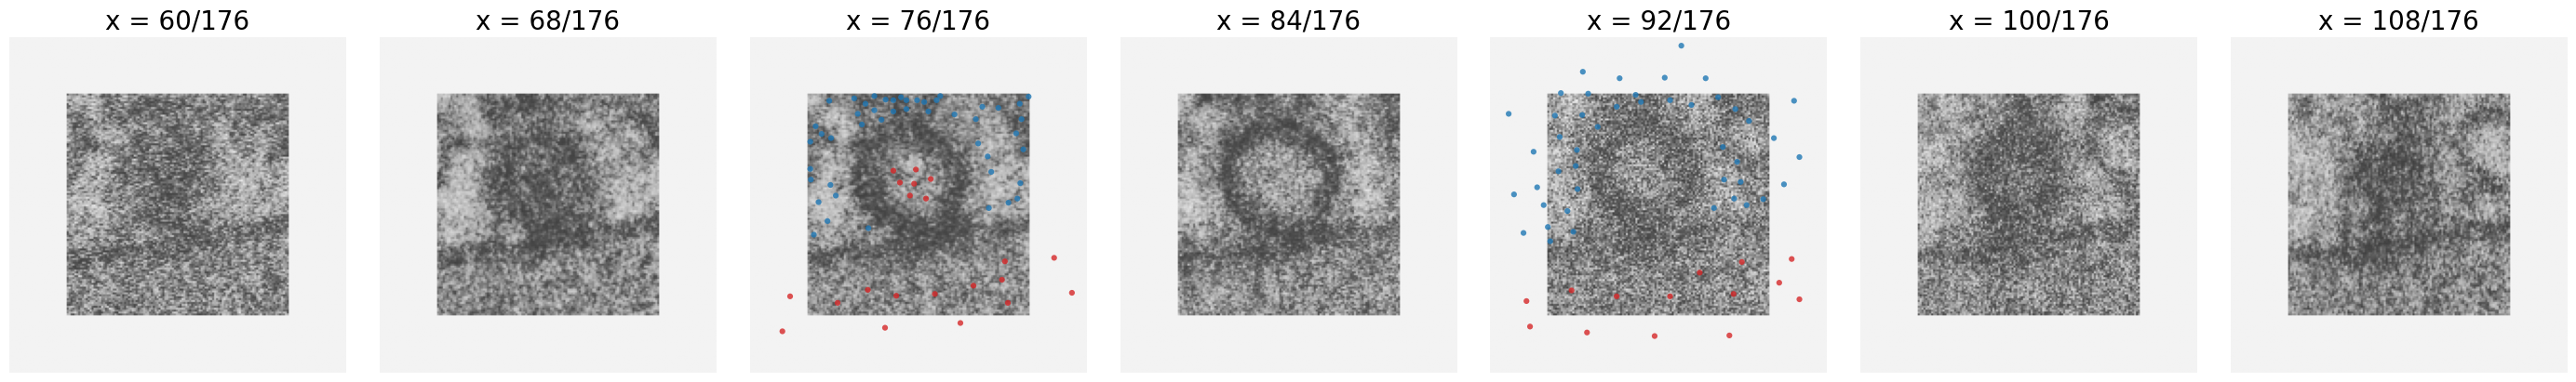

In [109]:
from pinn.utils import load_pts_data
from data_generation.preprocess import overlay_points_on_cryoet

#### Visualize data ####
sign = load_pts_data(f"../data/experimental/pts/sign/{data_id}/pt_s_{shape}.npz", perm=(2,1,0))
inside  = sign["points"][sign["label"] == 1]
outside = sign["points"][sign["label"] == -1]
overlays = [
    {"data": inside,  "label": "Inside",  "color": "tab:red"},
    {"data": outside, "label": "Outside", "color": "tab:blue"},
]
overlay_points_on_cryoet(cryoet=clahe_vol, overlays=overlays, axis='x', slice_index=slices, cryo_alpha=0.8, show_title=True)

### Physics loss evaluation points
Extact these points randomly within the computational domain

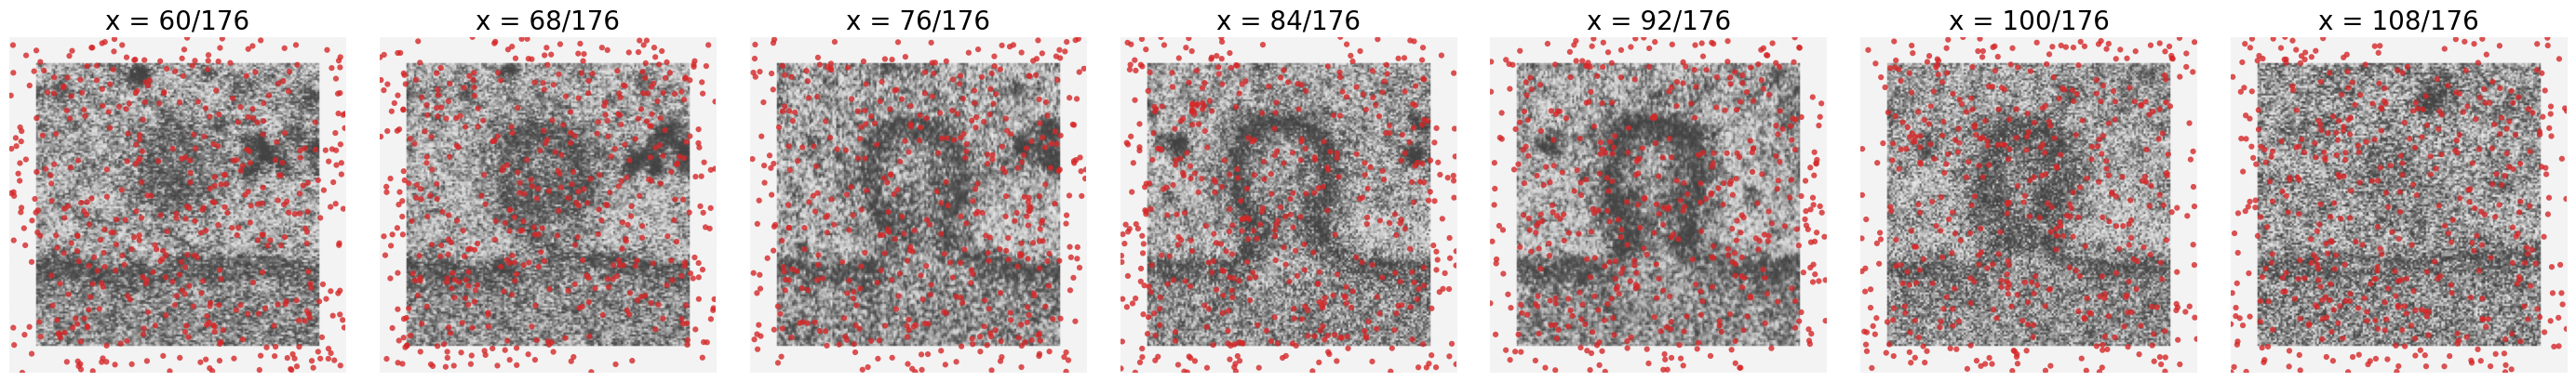

In [118]:
import jax

#### Randomly sample collocation points ####
# seed = 0
# key = jax.random.PRNGKey(seed)
# num_collocation = 80000
# x_train = (jax.random.uniform(key, (num_collocation, 3), minval=-1, maxval=1))
# data_phys = {"points": x_train}
# meta_phys = {
#     "type": "phys",
#     "n_sample": num_collocation,
#     "seed": seed,
#     "sampling": "random",
# }

#### Save data ####
# save_pts_data(data_phys, f"../data/../data/experimental/pts/phys/pt_p_general.npz", meta_phys)

#### Visualize data ####
data = load_pts_data(f"../data/experimental/pts/phys/pt_p_general.npz", perm=(2,1,0))
phys = data["points"]
overlays = [
    {"data": phys, "label": "Physics", "color": "tab:red"},
]
overlay_points_on_cryoet(cryoet=clahe_vol, overlays=overlays, axis='x', slice_index=slices, cryo_alpha=0.8, show_title=True)

#### Smoothing loss evaluation points
These points are automatically extracted after stage 1

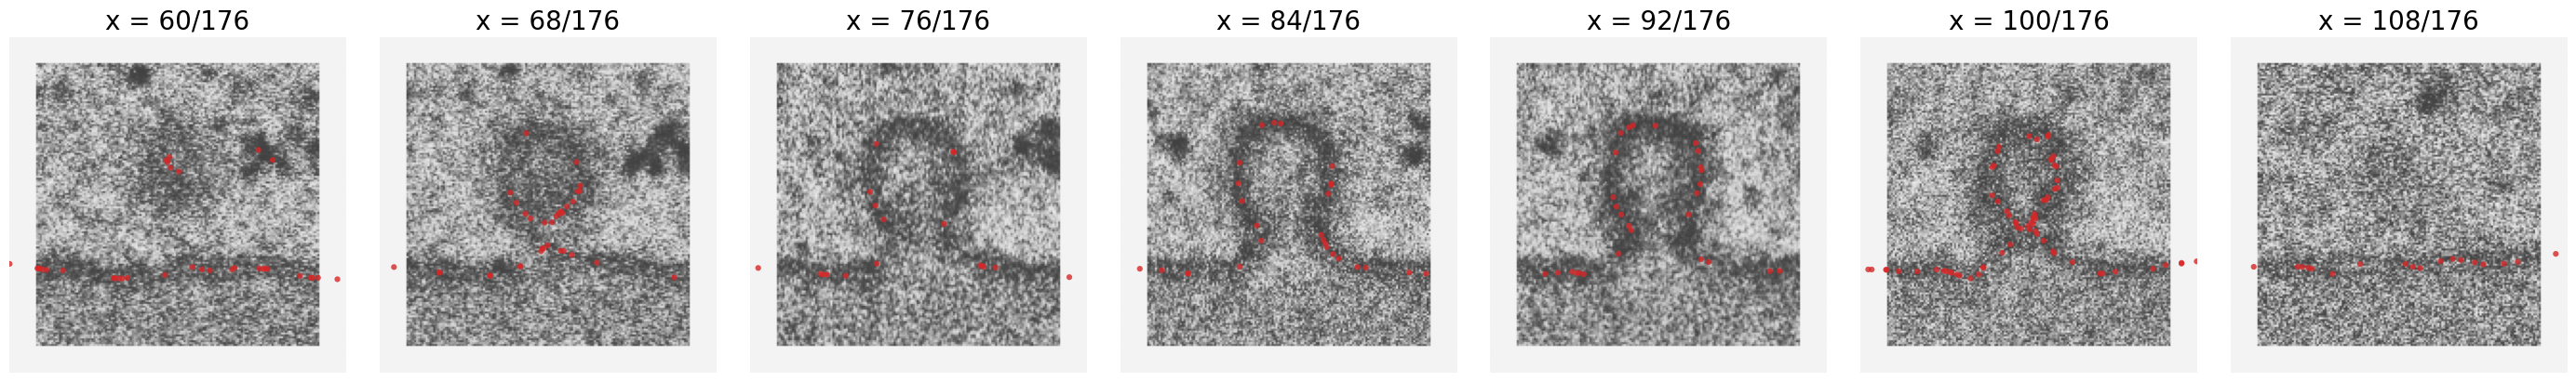

In [9]:
#### Visualize data ####
data = load_pts_data(f"../data/experimental/pts/curv/{data_id}/pt_c_{shape}.npz", perm=(2,1,0))
curv = data["points"]
overlays = [
    {"data": curv, "label": "Physics", "color": "tab:red"},
]
overlay_points_on_cryoet(cryoet=clahe_vol, overlays=overlays, axis='x', slice_index=slices, cryo_alpha=0.8, show_title=True)

In [155]:
## To reload

import importlib
import data_generation.preprocess as preprocess

importlib.reload(preprocess)

<module 'data_generation.preprocess' from '/mmfs1/gscratch/matsulab/sim/pinn-exploration-model/src/data_generation/preprocess.py'>